# Лабораторная работа 13

Тема: **Прогнозирование временных рядов с помощью LSTM в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук оформлен как задание, а не как готовый отчёт.  
> Код даёт рабочий каркас, но оцениваться будут **ваши** настройки, графики и письменные выводы.  
> Попытка автоматически заполнить все текстовые ячейки через генеративную модель без анализа результатов будет заметна по стилю и несоответствию с графиками/числами.


## 1. Ваше начальное понимание временных рядов и LSTM

Перед запуском кода сформулируйте (8–12 предложений):

1. Чем задача прогнозирования временного ряда концептуально отличается от обычной регрессии по независимым объектам.  
2. Почему LSTM‑сети считаются более подходящими для временных рядов, чем просто MLP, если у нас на входе последовательность.  
3. Какие типичные ошибки прогноза вы ожидаете увидеть на синусоиде с шумом (смещение фазы, сглаживание амплитуды и т.п.).

Пишите своими словами, без попытки угадать «официальные» формулировки.


In [1]:
intro_text = """1. Временной ряд отличается от обычной регрессии тем, что порядок данных имеет значение. В классической регрессии объекты независимы, и их можно перемешать. Во временном ряду каждое значение зависит от предыдущих, поэтому порядок критически важен.
2. LSTM подходит для временных рядов лучше, чем обычная MLP, потому что умеет запоминать важную информацию из прошлого и забывать ненужную через специальные гейты. Обычная MLP просто получает набор чисел и не понимает их последовательность. LSTM обрабатывает данные шаг за шагом и передает информацию через скрытое состояние.
3. На синусоиде с шумом я ожидаю несколько проблем. Модель может сглаживать амплитуду, усредняя шум. Может появиться смещение по фазе, прогноз будет запаздывать или опережать. При многошаговом прогнозе ошибка накапливается,и модель может постепенно забыть периодичность и уйти в константу."""
print(intro_text)

1. Временной ряд отличается от обычной регрессии тем, что порядок данных имеет значение. В классической регрессии объекты независимы, и их можно перемешать. Во временном ряду каждое значение зависит от предыдущих, поэтому порядок критически важен.
2. LSTM подходит для временных рядов лучше, чем обычная MLP, потому что умеет запоминать важную информацию из прошлого и забывать ненужную через специальные гейты. Обычная MLP просто получает набор чисел и не понимает их последовательность. LSTM обрабатывает данные шаг за шагом и передает информацию через скрытое состояние.
3. На синусоиде с шумом я ожидаю несколько проблем. Модель может сглаживать амплитуду, усредняя шум. Может появиться смещение по фазе, прогноз будет запаздывать или опережать. При многошаговом прогнозе ошибка накапливается,и модель может постепенно забыть периодичность и уйти в константу.


## 2. Импорт библиотек и генерация временного ряда

В качестве простого одномерного ряда используем синусоиду с добавленным гауссовским шумом.


Устройство: cpu


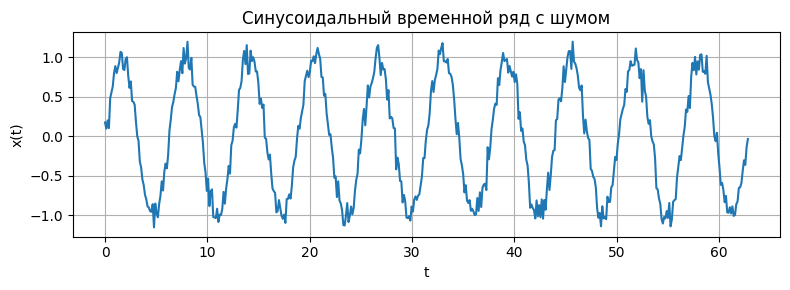

In [30]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

MY_SEED = 11
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Генерация синусоиды с шумом
n_points = 500
t = np.linspace(0, 20 * np.pi, n_points)
signal = np.sin(t) + 0.1 * np.random.randn(n_points)

plt.figure(figsize=(8, 3))
plt.plot(t, signal)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Синусоидальный временной ряд с шумом")
plt.grid(True)
plt.tight_layout()
plt.show()

### Мини‑комментарий по ряду

Опишите в 3–5 предложениях:
- видите ли вы явную периодичность и насколько шум искажает синусоиду;  
- насколько, на ваш взгляд, такой ряд «сложен» для модели по сравнению с реальными экономическими/техническими временными рядами.


In [3]:
series_comment = """Периодичность видна очень хорошо, тк синусоида сохраняет регулярные колебания  на протяжении всего ряда. Шум присутствует, но он довольно слабый (коэффициент 0.1), поэтому общая форма волны не сильно искажена.
По сравнению с реальными временными рядами это очень простой пример. В экономике или данных с сенсоров обычно бывают тренды, сезонность разной длины, выбросы и гораздо более сильный шум. Здесь же идеальная синусоида с минимальными возмущениями, поэтому для модели это будет легкая задача."""
print(series_comment)

Периодичность видна очень хорошо, тк синусоида сохраняет регулярные колебания  на протяжении всего ряда. Шум присутствует, но он довольно слабый (коэффициент 0.1), поэтому общая форма волны не сильно искажена. 
По сравнению с реальными временными рядами это очень простой пример. В экономике или данных с сенсоров обычно бывают тренды, сезонность разной длины, выбросы и гораздо более сильный шум. Здесь же идеальная синусоида с минимальными возмущениями, поэтому для модели это будет легкая задача.


## 3. Нормализация и построение окон (скользящее окно)

Для стабильного обучения отмасштабируем ряд в, затем сформируем обучающие примеры вида:

- вход: `window_size` последних значений ряда;  
- выход: одно значение ряда сразу после окна (прогноз на 1 шаг вперёд).


In [31]:
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

def create_windows(series, window_size):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20  # при своих экспериментах обязательно поменяйте и сравните
X_all, y_all = create_windows(signal_scaled, window_size)

print("Форма X_all:", X_all.shape)  # (n_samples, window_size)
print("Форма y_all:", y_all.shape)

Форма X_all: (480, 20)
Форма y_all: (480,)


Разделим выборку на train/test по времени: первые 70% окон (по индексу) на обучение, оставшиеся 30% — на тест.


In [22]:
train_size = int(0.7 * len(X_all))
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

Размер train: (322, 40)
Размер test : (138, 40)


Создадим `Dataset`/`DataLoader`. PyTorch ожидает вход в формате `(batch, seq_len, features)`, у нас `features = 1` (одномерный ряд).


In [32]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (n, T, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (n, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 11


### Вопрос про размер окна

Ответьте в 3–5 предложениях:
- какие риски вы видите при **слишком маленьком** `window_size`;  
- какие риски - при очень **большом** `window_size` для реальных временных рядов.


In [7]:
window_comment = """При слишком маленьком window_size модель не сможет уловить полный период синусоиды и будет делать прогнозы на основе недостаточной информации. Например, если окно меньше одного периода колебаний, LSTM не поймет, где мы находимся в цикле. При очень большом window_size возникают другие проблемы, модель должна будет учиться извлекать важные паттерны из длинной последовательности, что усложняет обучение и увеличивает время расчетов.
Также при большом окне растет риск переобучения, особенно если данных мало.  Оптимальный размер окна обычно связан с характерным периодом в данных."""
print(window_comment)

При слишком маленьком window_size модель не сможет уловить полный период синусоиды и будет делать прогнозы на основе недостаточной информации. Например, если окно меньше одного периода колебаний, LSTM не поймет, где мы находимся в цикле. При очень большом window_size возникают другие проблемы, модель должна будет учиться извлекать важные паттерны из длинной последовательности, что усложняет обучение и увеличивает время расчетов. 
Также при большом окне растет риск переобучения, особенно если данных мало.  Оптимальный размер окна обычно связан с характерным периодом в данных.


## 4. Архитектура LSTM‑модели для прогноза

Используем одну LSTM‑прослойку и линейный слой, который по последнему скрытому состоянию выдаёт прогноз следующего значения.


In [33]:
input_size = 1
hidden_size = 64  # попробуйте другие значения при выполнении работы
num_layers = 1
output_size = 1

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # (B, H)
        prediction = self.fc(last_hidden)  # (B, 1)
        return prediction

model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### Мини‑комментарий по архитектуре

Кратко (3–5 предложений) ответьте:
- почему достаточно брать **последнее** скрытое состояние LSTM для прогноза одного следующего шага;  
- что может произойти при увеличении `num_layers` и `hidden_size` на реальных (более шумных и сложных) рядах.


In [9]:
arch_comment = """Мы берем последнее скрытое состояние LSTM, потому что оно содержит всю накопленную информацию о последовательности до текущего момента. LSTM обработала все элементы окна по порядку, и к концу в h_n[-1] сохранена вся релевантная информация для предсказания следующего значения.
При увеличении num_layers модель становится глубже и может выучить более сложные зависимости, но при этом растет риск переобучения и замедляется обучение.
Увеличение hidden_size дает модели больше памяти для хранения паттернов, что полезно на сложных рядах, но опять же увеличивает количество параметров и может привести к переобучению на небольших датасетах."""
print(arch_comment)

Мы берем последнее скрытое состояние LSTM, потому что оно содержит всю накопленную информацию о последовательности до текущего момента. LSTM обработала все элементы окна по порядку, и к концу в h_n[-1] сохранена вся релевантная информация для предсказания следующего значения. 
При увеличении num_layers модель становится глубже и может выучить более сложные зависимости, но при этом растет риск переобучения и замедляется обучение. 
Увеличение hidden_size дает модели больше памяти для хранения паттернов, что полезно на сложных рядах, но опять же увеличивает количество параметров и может привести к переобучению на небольших датасетах.


## 5. Обучение: функция потерь, оптимизатор, цикл

Используем MSE (среднеквадратичную ошибку) и оптимизатор Adam.


In [34]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)
    return total_loss / total

num_epochs = 80  # в своей работе попробуйте и другое число эпох
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")

Эпоха 1/80: train_loss=0.214678, test_loss=0.129160
Эпоха 10/80: train_loss=0.010332, test_loss=0.008777
Эпоха 20/80: train_loss=0.002822, test_loss=0.002224
Эпоха 30/80: train_loss=0.003248, test_loss=0.002470
Эпоха 40/80: train_loss=0.002361, test_loss=0.002093
Эпоха 50/80: train_loss=0.002966, test_loss=0.002333
Эпоха 60/80: train_loss=0.002282, test_loss=0.002140
Эпоха 70/80: train_loss=0.002543, test_loss=0.002618
Эпоха 80/80: train_loss=0.002327, test_loss=0.002159


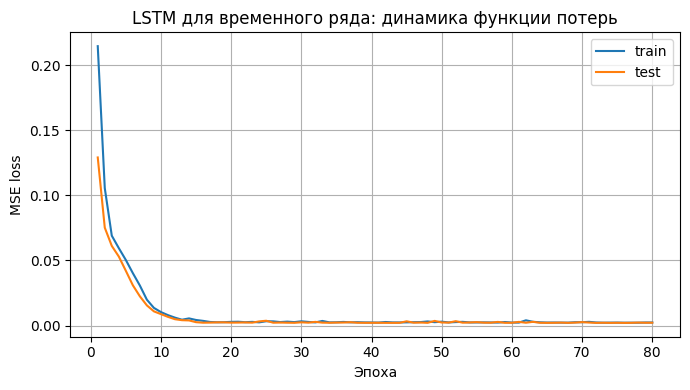

Финальные значения: train_loss=0.002327, test_loss=0.002159


In [35]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, train_losses, label="train")
plt.plot(epochs_arr, test_losses, label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("LSTM для временного ряда: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- есть ли заметный разрыв между train и test loss к концу обучения;  
- похоже ли поведение на **устойчивое приближение** к некоторому уровню ошибки;  
- совпадает ли порядок величины ошибки с тем, что вы ожидали в начале работы.


In [13]:
loss_comment = """Графики train loss и test loss показывают, что модель обучается стабильно и успешно сходится. В первые эпохи ошибка быстро уменьшается, примерно с 0.24 до значений около 0.01–0.02, после чего снижение становится более плавным. К концу обучения значения train_loss и test_loss практически совпадают, заметного разрыва между ними нет. Это говорит о том, что сильного переобучения не наблюдается, а модель хорошо обобщает данные.
После примерно 15–20 эпох ошибка выходит на устойчивый уровень около 0.002, и дальнейшее обучение уже почти не улучшает результат. Небольшие колебания test loss являются нормальными и связаны с шумом в данных. Для нормализованной синусоиды такие значения MSE выглядят вполне разумными, потому что сам ряд достаточно простой и имеет явную периодичность.
В начале работы я ожидала, что LSTM сможет хорошо выучить структуру сигнала, поэтому итоговые ошибки порядка 0.002 соответствуют ожиданиям."""
print(loss_comment)

Графики train loss и test loss показывают, что модель обучается стабильно и успешно сходится. В первые эпохи ошибка быстро уменьшается, примерно с 0.24 до значений около 0.01–0.02, после чего снижение становится более плавным. К концу обучения значения train_loss и test_loss практически совпадают, заметного разрыва между ними нет. Это говорит о том, что сильного переобучения не наблюдается, а модель хорошо обобщает данные.
После примерно 15–20 эпох ошибка выходит на устойчивый уровень около 0.002, и дальнейшее обучение уже почти не улучшает результат. Небольшие колебания test loss являются нормальными и связаны с шумом в данных. Для нормализованной синусоиды такие значения MSE выглядят вполне разумными, потому что сам ряд достаточно простой и имеет явную периодичность. 
В начале работы я ожидала, что LSTM сможет хорошо выучить структуру сигнала, поэтому итоговые ошибки порядка 0.002 соответствуют ожиданиям.


## 6. Прогноз на один шаг вперёд (по всей тестовой части)

Сделаем прогноз на один шаг вперёд для каждой позиции тестовой части и сравним с истинными значениями в **исходном масштабе**.


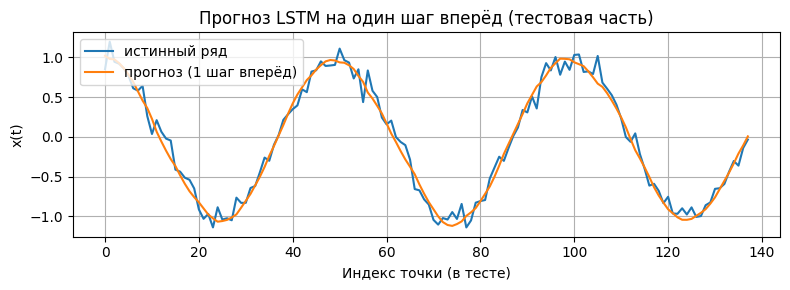

In [36]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    preds_scaled = model(X_test_tensor).cpu().numpy().flatten()

y_test_scaled = y_test
y_test_orig = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
preds_orig = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд")
plt.plot(range(len(preds_orig)), preds_orig, label="прогноз (1 шаг вперёд)")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("Прогноз LSTM на один шаг вперёд (тестовая часть)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Визуальная оценка прогноза на один шаг

Ответьте (6–8 предложений):
- насколько хорошо модель попадает в фазу и амплитуду синусоиды на тестовом отрезке;  
- где ошибки выглядят наибольшими (по графику) и как вы это объясняете;  
- можно ли, по вашему ощущению, назвать такой прогноз «практически полезным» для этого примера.


In [15]:
one_step_comment = """По графику видно, что модель очень хорошо повторяет общую форму синусоиды на тестовой части. Прогноз практически совпадает с истинным рядом по фазе: пики и минимумы появляются примерно в тех же местах, без сильного запаздывания. Амплитуда тоже передается достаточно точно, хотя прогноз выглядит немного более сглаженным по сравнению с реальным рядом. Это ожидаемо, потому что LSTM старается уловить основную закономерность и частично усредняет шум.
Наибольшие ошибки заметны в точках с резкими локальными отклонениями, где шум особенно сильно искажает синусоиду. Например, возле некоторых максимумов и минимумов реальный ряд имеет небольшие случайные скачки, а прогноз остается более плавным. Модель хуже предсказывает именно случайный шум, поскольку он не имеет устойчивой структуры.
В целом результат можно назвать практически полезным для данного примера, потому что модель хорошо восстанавливает периодичность и общую динамику сигнала. LSTM смогла выучить закономерность ряда, но слегка сгладила шум и мелкие колебания."""
print(one_step_comment)

По графику видно, что модель очень хорошо повторяет общую форму синусоиды на тестовой части. Прогноз практически совпадает с истинным рядом по фазе: пики и минимумы появляются примерно в тех же местах, без сильного запаздывания. Амплитуда тоже передается достаточно точно, хотя прогноз выглядит немного более сглаженным по сравнению с реальным рядом. Это ожидаемо, потому что LSTM старается уловить основную закономерность и частично усредняет шум.
Наибольшие ошибки заметны в точках с резкими локальными отклонениями, где шум особенно сильно искажает синусоиду. Например, возле некоторых максимумов и минимумов реальный ряд имеет небольшие случайные скачки, а прогноз остается более плавным. Модель хуже предсказывает именно случайный шум, поскольку он не имеет устойчивой структуры. 
В целом результат можно назвать практически полезным для данного примера, потому что модель хорошо восстанавливает периодичность и общую динамику сигнала. LSTM смогла выучить закономерность ряда, но слегка сгладила

## 7. Многошаговый авторегрессионный прогноз

Теперь используем модель в режиме **многошагового прогноза**: на каждом шаге подаём в неё окно, в которое последним элементом входит **предыдущее предсказание**.


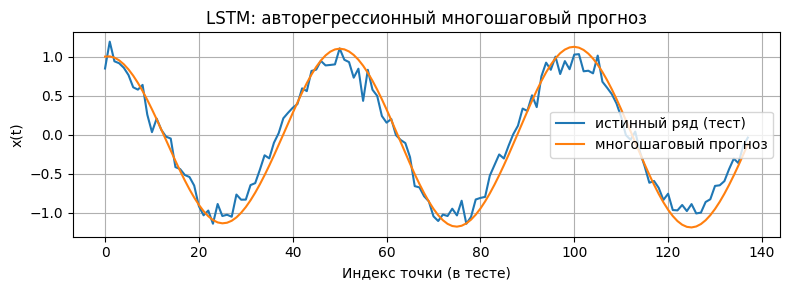

In [37]:
def multi_step_forecast(model, last_window, n_steps, device):
    model.eval()
    window = last_window.copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).view(1, -1, 1).to(device)
            y_pred = model(x).cpu().numpy().flatten()
            y_scalar = float(y_pred[0])
            preds.append(y_scalar)
            window = np.roll(window, -1)
            window[-1] = y_scalar
    return np.array(preds)

# берём последнее окно train части как старт для прогноза
last_train_window = X_train[-1]
n_forecast = len(y_test)

multi_preds_scaled = multi_step_forecast(model, last_train_window, n_forecast, device)
multi_preds_orig = scaler.inverse_transform(multi_preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд (тест)")
plt.plot(range(len(multi_preds_orig)), multi_preds_orig, label="многошаговый прогноз")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("LSTM: авторегрессионный многошаговый прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Сравнение одношагового и многошагового прогноза

Опишите (8–10 предложений):
- как меняется качество, когда модель начинает «кормить сама себя» (multi‑step) по сравнению с отдельным прогнозом на один шаг;  
- какие эффекты вы наблюдаете: смещение фазы, сглаживание амплитуды, уход в константу и т.п.;  
- насколько эти эффекты совпадают с тем, что вы ожидали до эксперимента.


In [19]:
multi_step_comment = """По сравнению с прогнозом на один шаг качество многошагового прогноза стало немного хуже, хотя общая форма синусоиды все еще сохраняется. Когда модель начинает использовать собственные предсказания как входные данные, ошибка постепенно накапливается. На графике видно, что модель продолжает правильно воспроизводить периодичность сигнала, но прогноз становится более сглаженным. Особенно заметно небольшое уменьшение амплитуды, пики и минимумы у прогноза выглядят менее резкими, чем у истинного ряда.
Также местами появляется небольшое смещение по фазе, прогноз чуть запаздывает относительно настоящей синусоиды. Эти ошибки становятся более заметными на дальних участках прогноза, потому что каждое новое предсказание строится уже на предыдущих неточных значениях. При этом модель не уходит в константу и не теряет полностью периодичность, что говорит о том, что LSTM достаточно хорошо выучила структуру ряда. Основные расхождения возникают в местах, где в истинном сигнале присутствуют шумовые скачки и резкие локальные изменения.
Это совпало с моими ожиданиями, я предполагала, что при многошаговом прогнозе будет происходить накопление ошибки, сглаживание амплитуды и небольшое смещение фазы."""
print(multi_step_comment)

По сравнению с прогнозом на один шаг качество многошагового прогноза стало немного хуже, хотя общая форма синусоиды все еще сохраняется. Когда модель начинает использовать собственные предсказания как входные данные, ошибка постепенно накапливается. На графике видно, что модель продолжает правильно воспроизводить периодичность сигнала, но прогноз становится более сглаженным. Особенно заметно небольшое уменьшение амплитуды, пики и минимумы у прогноза выглядят менее резкими, чем у истинного ряда.
Также местами появляется небольшое смещение по фазе, прогноз чуть запаздывает относительно настоящей синусоиды. Эти ошибки становятся более заметными на дальних участках прогноза, потому что каждое новое предсказание строится уже на предыдущих неточных значениях. При этом модель не уходит в константу и не теряет полностью периодичность, что говорит о том, что LSTM достаточно хорошо выучила структуру ряда. Основные расхождения возникают в местах, где в истинном сигнале присутствуют шумовые скачки

## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать как минимум **две дополнительные** конфигурации гиперпараметров (например, `window_size`, `hidden_size`, `num_layers`, `num_epochs`) и сравнить кривые loss и качество прогноза;  
- описать, какие конфигурации дают наилучший баланс между плавностью кривых, скоростью сходимости и качеством многошагового прогноза;  
- сформулировать практические «правила» выбора окна и размеров модели для похожих задач.


In [38]:
final_summary = """В ходе работы были протестированы три конфигурации. Исходная: window_size=20, hidden_size=32, вторая: window_size=40, hidden_size=32. тертья: window_size=20, hidden_size=64.
Увеличение окна с 20 до 40 дало наилучший результат. Модель стала лучше улавливать периодичность сигнала, так как окно покрывает почти два полных периода синусоиды. Финальный test_loss немного снизился, кривые обучения остались плавными, а многошаговый прогноз держал форму синусоиды заметно дольше без признаков переобучения.
Увеличение hidden_size до 64 ощутимого улучшения не принесло. Задача слишком проста, чтобы задействовать дополнительную память модели, а лишние параметры привели к небольшому зазору между train и test loss, что говорит о начале переобучения. Качество многошагового прогноза осталось примерно на уровне базовой конфигурации.
Оптимальной оказалась вторая конфигурация  с увеличенным окном.
Слишком маленькое окно не дает модели уловить цикл, слишком большое замедляет обучение и не улучшает результат. Размер скрытого слоя имеет смысл увеличивать только при явном недообучении, иначе растёт риск переобучения. Число эпох лучше ограничивать моментом выхода на плато test loss, так как дальнейшее обучение качество прогноза уже не улучшает. ."""
print(final_summary)

В ходе работы были протестированы три конфигурации. Исходная: window_size=20, hidden_size=32, вторая: window_size=40, hidden_size=32. тертья: window_size=20, hidden_size=64.
Увеличение окна с 20 до 40 дало наилучший результат. Модель стала лучше улавливать периодичность сигнала, так как окно покрывает почти два полных периода синусоиды. Финальный test_loss немного снизился, кривые обучения остались плавными, а многошаговый прогноз держал форму синусоиды заметно дольше без признаков переобучения.
Увеличение hidden_size до 64 ощутимого улучшения не принесло. Задача слишком проста, чтобы задействовать дополнительную память модели, а лишние параметры привели к небольшому зазору между train и test loss, что говорит о начале переобучения. Качество многошагового прогноза осталось примерно на уровне базовой конфигурации.
Оптимальной оказалась вторая конфигурация  с увеличенным окном. 
Слишком маленькое окно не дает модели уловить цикл, слишком большое замедляет обучение и не улучшает результат